# CoPro Tutorial: Two Cell Types (Brain MERFISH)

This tutorial demonstrates how to run CoPro on a **two cell type** dataset. We use a brain MERFISH dataset from Zhang et al. *Nature* 2023, focusing on the co-progression between **D1 neurons** (`061 STR D1 Gaba`) and **D2 neurons** (`062 STR D2 Gaba`) in the striatum.

**What CoPro finds here:** The spatial co-progression between D1 and D2 neurons captures a coordinated spatial gradient — cells of the same transcriptional state in both types cluster together spatially, reflecting shared developmental or positional identity along the striatum axis.

## Overview

1. Load and preprocess gene expression data
2. Build a `CoProSingle` object
3. Run the full CoPro pipeline
4. Select the optimal sigma value
5. Visualize cross-type spatial correlation
6. Visualize cell scores in space
7. Examine top genes associated with co-progression

**Reference:**  
Zhang, M., Pan, X., Jung, W. *et al.* Molecularly defined and spatially resolved cell atlas of the whole mouse brain. *Nature* 624, 343–354 (2023). https://doi.org/10.1038/s41586-023-06808-9

## 1. Load packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import zscore

import copro as cp

print(f"copro version: {cp.__version__}")

copro version: 0.1.1


## 2. Set parameters

In [2]:
N_PCA = 40
CELL_TYPE_A = "061 STR D1 Gaba"   # D1 neurons
CELL_TYPE_B = "062 STR D2 Gaba"   # D2 neurons
CELL_TYPES = [CELL_TYPE_A, CELL_TYPE_B]
SIGMA_VALUES = [0.1, 0.14, 0.2, 0.5]
N_CC = 2                           # number of canonical components

## 3. Load data

The input data consists of:
- **Expression matrix** — cells × genes, normalized counts
- **Metadata** — must include `x`, `y` spatial coordinates and a cell type column

Replace the paths below with your own files. The expression matrix can be a CSV (cells × genes) or any tabular format readable by pandas.

In [3]:
# ── Data paths ────────────────────────────────────────────────────────────────
DATA_DIR = "/Users/zhenmiao/Dropbox/Zhuang-ABCA-1.054_1"
EXPR_FILE = f"{DATA_DIR}/Zhuang_ABCA_1.054_subset_expression_data.csv"
META_FILE = f"{DATA_DIR}/Zhuang_ABCA_1.054_subset_metadata.csv"

expr_df = pd.read_csv(EXPR_FILE, index_col=0)
meta    = pd.read_csv(META_FILE, index_col=0)

# Use cell_label as index
meta.index = meta["cell_label"].astype(str)
expr_df.index = meta.index

# Keep only the two cell types of interest
keep_mask = meta["subclass"].isin(CELL_TYPES)
expr_df = expr_df.loc[keep_mask]
meta    = meta.loc[keep_mask]

# Ensure coordinates are numeric
meta["x"] = pd.to_numeric(meta["x"])
meta["y"] = pd.to_numeric(meta["y"])

print(f"Cells: {expr_df.shape[0]}   Genes: {expr_df.shape[1]}")
print(meta["subclass"].value_counts().to_string())
meta.head()

Cells: 5245   Genes: 1122
subclass
061 STR D1 Gaba    2840
062 STR D2 Gaba    2405


,X,cell_label,brain_section_label,feature_matrix_label,donor_label,donor_genotype,donor_sex,cluster_alias,x,y,z,subclass_confidence_score,cluster_confidence_score,high_quality_transfer,neurotransmitter,class,subclass,supertype,cluster
cell_label,,,,,,,,,,,,,,,,,,,
123183753206196126981335125253769778290,2396455,123183753206196126981335125253769778290,Zhuang-ABCA-1.054,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,1090,2.845499,4.190669,4.582388,0.999982,0.738142,True,GABA,09 CNU-LGE GABA,061 STR D1 Gaba,0268 STR D1 Gaba_4,0953 STR D1 Gaba_4
172243084673348347504961833909017846001,2396465,172243084673348347504961833909017846001,Zhuang-ABCA-1.054,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,1086,2.863455,4.203201,4.582388,0.999980,0.542462,True,GABA,09 CNU-LGE GABA,062 STR D2 Gaba,0277 STR D2 Gaba_4,0979 STR D2 Gaba_4
208921743301012915256921668563006021943,2396470,208921743301012915256921668563006021943,Zhuang-ABCA-1.054,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,1088,2.880213,4.283328,4.582388,0.949479,0.561473,True,GABA,09 CNU-LGE GABA,062 STR D2 Gaba,0277 STR D2 Gaba_4,0981 STR D2 Gaba_4
27028238262666084007449255718349178779,2396479,27028238262666084007449255718349178779,Zhuang-ABCA-1.054,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,1090,2.844902,4.177975,4.582388,0.999973,0.938373,True,GABA,09 CNU-LGE GABA,061 STR D1 Gaba,0268 STR D1 Gaba_4,0953 STR D1 Gaba_4
317609247442583415813450448683138942486,2396492,317609247442583415813450448683138942486,Zhuang-ABCA-1.054,Zhuang-ABCA-1,Zhuang-ABCA-1,wt/wt,F,1090,2.831068,4.150687,4.582388,0.999984,0.945823,True,GABA,09 CNU-LGE GABA,061 STR D1 Gaba,0268 STR D1 Gaba_4,0953 STR D1 Gaba_4


## 4. Preprocess

### 4a. Normalize expression

If your expression matrix contains **raw counts**, apply normalization here (e.g., log1p, size-factor normalization). If the data is **already normalized** (as is the case for the MERFISH dataset used here, which is provided as log-transformed counts), use it as-is.

In [4]:
# Use expression data as-is (already log-normalized for this MERFISH dataset)
expr_norm = expr_df.values.astype(float)

# For raw count data, apply normalization first, e.g.:
# expr_norm = np.log1p(expr_df.values.astype(float))

print(f"Expression matrix shape: {expr_norm.shape}")

# Save gene names for later
gene_names = list(expr_df.columns)

Expression matrix shape: (5245, 1122)


### 4b. Prepare spatial coordinates

For MERFISH data the `x` and `y` columns in the metadata are already in physical units (micrometers). CoPro uses sigma values in the same unit as the coordinates — choose sigma values on the scale of typical cell-to-cell distances in your tissue.

In [5]:
# Spatial coordinates — use as-is (already in physical units)
location = meta[["x", "y"]].reset_index(drop=True)

# Cell type labels
cell_types = meta["subclass"].values

### 4c. Visualize spatial layout

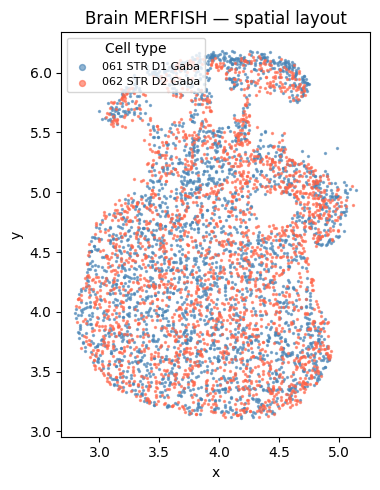

In [6]:
colors_map = {CELL_TYPE_A: "steelblue", CELL_TYPE_B: "tomato"}

fig, ax = plt.subplots(figsize=(6, 5))
for ct, color in colors_map.items():
    mask = cell_types == ct
    ax.scatter(location.loc[mask, "x"], location.loc[mask, "y"],
               s=2, color=color, alpha=0.6, label=ct)
ax.legend(markerscale=3, fontsize=8, title="Cell type")
ax.set_title("Brain MERFISH — spatial layout")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 5. Build CoPro object and run pipeline

The CoPro pipeline consists of six steps:

| Step | Function | Description |
|------|----------|-------------|
| 1 | `subset_data` | Filter to cell types of interest |
| 2 | `compute_pca` | PCA on expression matrix per cell type |
| 3 | `compute_distance` | Pairwise spatial distances (within and between types) |
| 4 | `compute_kernel_matrix` | Gaussian RBF kernel over distances |
| 5 | `run_skr_cca` | SkrCCA optimization (power method) |
| 6 | `compute_normalized_correlation` | Spectral-norm normalized CCA correlation |
| 7 | `compute_gene_and_cell_scores` | Project weights to cell and gene space |

In [7]:
# Build object
obj = cp.CoProSingle(
    normalized_data=expr_norm,
    location_data=location,
    meta_data=meta.reset_index(drop=True),
    cell_types=cell_types,
)

# Run pipeline
obj = cp.subset_data(obj, CELL_TYPES)
obj = cp.compute_pca(obj, n_pca=N_PCA)
obj = cp.compute_distance(obj, normalize=False)
obj = cp.compute_kernel_matrix(
    obj,
    sigma_values=SIGMA_VALUES,
    upper_quantile=0.85,
    lower_limit=5e-7,
)
obj = cp.run_skr_cca(obj, scale_pcs=True, n_cc=N_CC)
obj = cp.compute_normalized_correlation(obj)
obj = cp.compute_gene_and_cell_scores(obj)

print(f"\nPipeline complete. Selected sigma: {obj.sigma_value_choice}")

Running SkrCCA for sigma = 0.1
Convergence reached at iteration 25 (max_diff=9.050e-06)
  Component convergence at iteration 0 (max_diff=2.220e-16)
Running SkrCCA for sigma = 0.14
Convergence reached at iteration 24 (max_diff=8.823e-06)
  Component convergence at iteration 0 (max_diff=4.441e-16)
Running SkrCCA for sigma = 0.2


Convergence reached at iteration 21 (max_diff=6.765e-06)
  Component convergence at iteration 0 (max_diff=3.053e-16)
Running SkrCCA for sigma = 0.5
Convergence reached at iteration 12 (max_diff=7.422e-06)
  Component convergence at iteration 0 (max_diff=1.631e-16)
Calculating spectral norms (may take a while)...


Finished calculating spectral norms.

Pipeline complete. Selected sigma: 0.1


## 6. Select optimal sigma

CoPro automatically selects the sigma value that maximizes the mean CC1 normalized correlation. We visualize the normalized correlation across all tested sigma values and canonical components (CCs), faceted by cell type pair and CC index.

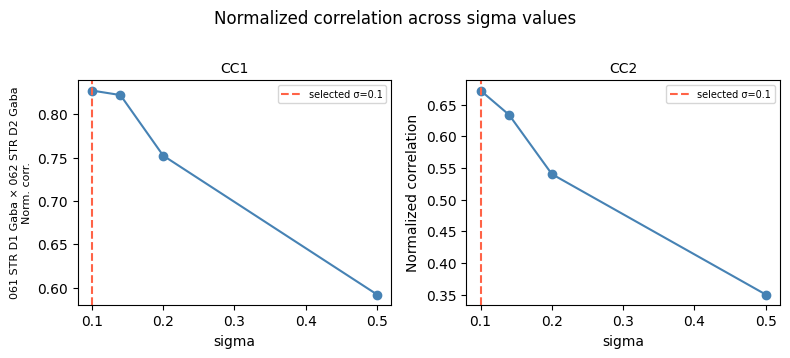

In [8]:
# Collect normalized correlations
nc_frames = []
for sigma_name, df in obj.normalized_correlation.items():
    if df is not None and len(df) > 0:
        nc_frames.append(df)
nc_df = pd.concat(nc_frames, ignore_index=True)

# Create a readable pair label
nc_df["pair"] = nc_df["cell_type_1"] + " × " + nc_df["cell_type_2"]

# Plot: one panel per (pair, CC)
pairs   = nc_df["pair"].unique()
cc_idxs = sorted(nc_df["CC_index"].unique())
n_cols  = len(cc_idxs)
n_rows  = len(pairs)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(4 * n_cols, 3.5 * n_rows),
                          sharey=False, squeeze=False)

for row_i, pair in enumerate(pairs):
    for col_i, cc in enumerate(cc_idxs):
        ax  = axes[row_i][col_i]
        sub = nc_df[(nc_df["pair"] == pair) & (nc_df["CC_index"] == cc)].sort_values("sigma")
        ax.plot(sub["sigma"], sub["normalized_correlation"], "o-", color="steelblue")
        ax.axvline(obj.sigma_value_choice, color="tomato", linestyle="--",
                   label=f"selected σ={obj.sigma_value_choice}")
        ax.set_title(f"CC{cc}", fontsize=10)
        ax.set_xlabel("sigma")
        ax.set_ylabel("Normalized correlation")
        ax.legend(fontsize=7)
        if col_i == 0:
            ax.set_ylabel(f"{pair}\nNorm. corr.", fontsize=8)

fig.suptitle("Normalized correlation across sigma values", y=1.01)
plt.tight_layout()
plt.show()

## 7. Cross-type spatial correlation scatter

For a two-type model, the objective is to find cell scores for each type that are spatially correlated *between* types (as mediated by the cross-type kernel K_AB). We visualize this by plotting the **kernel-smoothed A scores** (K_AB^T · scores_A) against the **raw B cell scores**.

Each point represents one cell from type B. The x-axis value is the weighted average of nearby type A cell scores (proximity defined by K_AB), and the y-axis is the B cell's own score. A positive correlation confirms that CoPro has found a spatially coordinated progression between the two types.

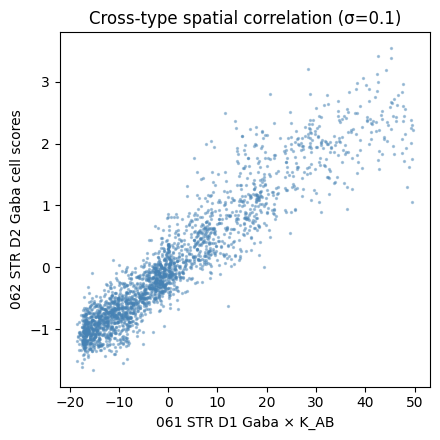

In [9]:
sigma = obj.sigma_value_choice

# CC1 scores
scores_A = obj.cell_scores[f"cellScores|sigma{sigma}|{CELL_TYPE_A}"][:, 0]  # (n_A,)
scores_B = obj.cell_scores[f"cellScores|sigma{sigma}|{CELL_TYPE_B}"][:, 0]  # (n_B,)

# Cross-type kernel K_AB: shape (n_A, n_B)
K_AB = obj.kernel_matrices[f"kernel|sigma{sigma}|{CELL_TYPE_A}|{CELL_TYPE_B}"]

# Kernel-smoothed A scores projected into B space: K_AB.T @ scores_A → shape (n_B,)
KA_scores = K_AB.T @ scores_A

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(KA_scores, scores_B, s=2, alpha=0.4, color="steelblue")
ax.set_xlabel(f"{CELL_TYPE_A} × K_AB")
ax.set_ylabel(f"{CELL_TYPE_B} cell scores")
ax.set_title(f"Cross-type spatial correlation (σ={sigma})")
plt.tight_layout()
plt.show()

## 8. Cell scores in situ

We visualize the CoPro cell scores spatially for both cell types. Cells with similar scores form coherent spatial regions, revealing the underlying tissue organization shared between D1 and D2 neurons.

### 8a. Continuous scores

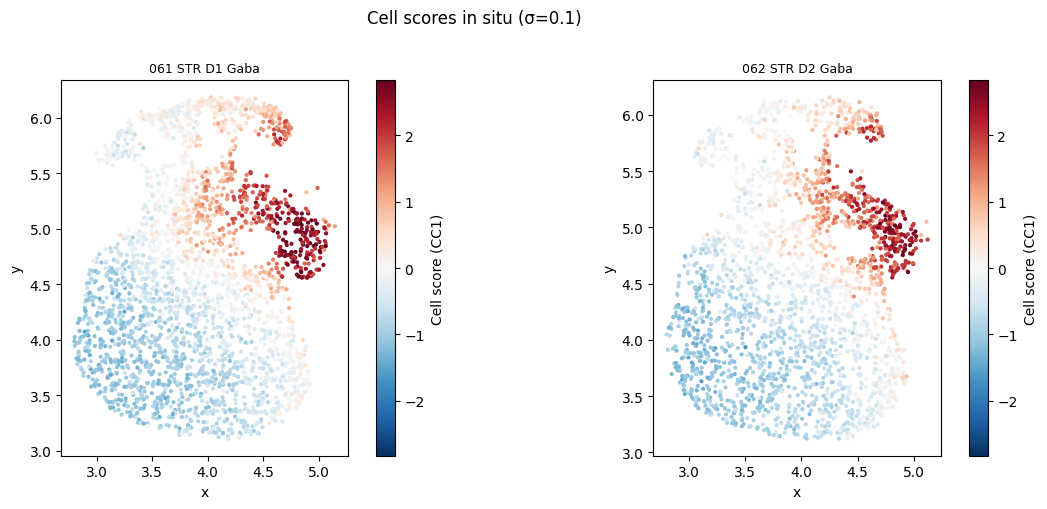

In [10]:
sigma = obj.sigma_value_choice

# Retrieve scores and spatial coordinates for each cell type
scores_A = obj.cell_scores[f"cellScores|sigma{sigma}|{CELL_TYPE_A}"][:, 0]
scores_B = obj.cell_scores[f"cellScores|sigma{sigma}|{CELL_TYPE_B}"][:, 0]

mask_A = obj.cell_types_sub == CELL_TYPE_A
mask_B = obj.cell_types_sub == CELL_TYPE_B
loc_A  = obj.location_data_sub[mask_A].reset_index(drop=True)
loc_B  = obj.location_data_sub[mask_B].reset_index(drop=True)

# Shared color scale across both types
all_scores = np.concatenate([scores_A, scores_B])
vabs = np.percentile(np.abs(all_scores), 99)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, scores, loc, ct in [
    (axes[0], scores_A, loc_A, CELL_TYPE_A),
    (axes[1], scores_B, loc_B, CELL_TYPE_B),
]:
    sc = ax.scatter(
        loc["x"], loc["y"],
        c=scores, cmap="RdBu_r", s=4,
        vmin=-vabs, vmax=vabs,
    )
    plt.colorbar(sc, ax=ax, label="Cell score (CC1)")
    ax.set_title(ct, fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle(f"Cell scores in situ (σ={sigma})", y=1.01)
plt.tight_layout()
plt.show()

### 8b. Binarized scores

We binarize the cell scores at the median for each type independently. This yields four categories: high/low for type A and high/low for type B, shown with distinct colors to highlight the spatial patterning.

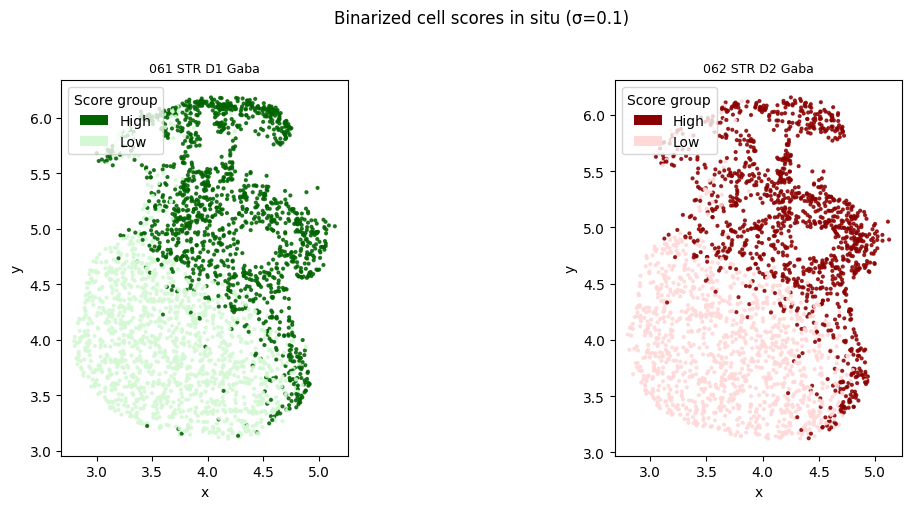

In [11]:
scores_A_bin = (scores_A > np.median(scores_A)).astype(int)
scores_B_bin = (scores_B > np.median(scores_B)).astype(int)

# Color scheme: A_high=darkgreen, A_low=light green, B_high=darkred, B_low=light red
color_A = np.where(scores_A_bin == 1, "darkgreen", "#d4f8d4")
color_B = np.where(scores_B_bin == 1, "darkred",   "#ffd8d8")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, color, loc, ct, labels, palette in [
    (axes[0], color_A, loc_A, CELL_TYPE_A,
     ["High", "Low"], ["darkgreen", "#d4f8d4"]),
    (axes[1], color_B, loc_B, CELL_TYPE_B,
     ["High", "Low"], ["darkred",   "#ffd8d8"]),
]:
    ax.scatter(loc["x"], loc["y"], c=color, s=4, alpha=0.8)
    # Legend patches
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=l) for c, l in zip(palette, labels)]
    ax.legend(handles=legend_elements, title="Score group", markerscale=2)
    ax.set_title(ct, fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle(f"Binarized cell scores in situ (σ={sigma})", y=1.01)
plt.tight_layout()
plt.show()

## 9. Top genes associated with co-progression

Gene scores reflect how strongly each gene is associated with the spatial co-progression axis. We display the top genes for CC1 in each cell type.

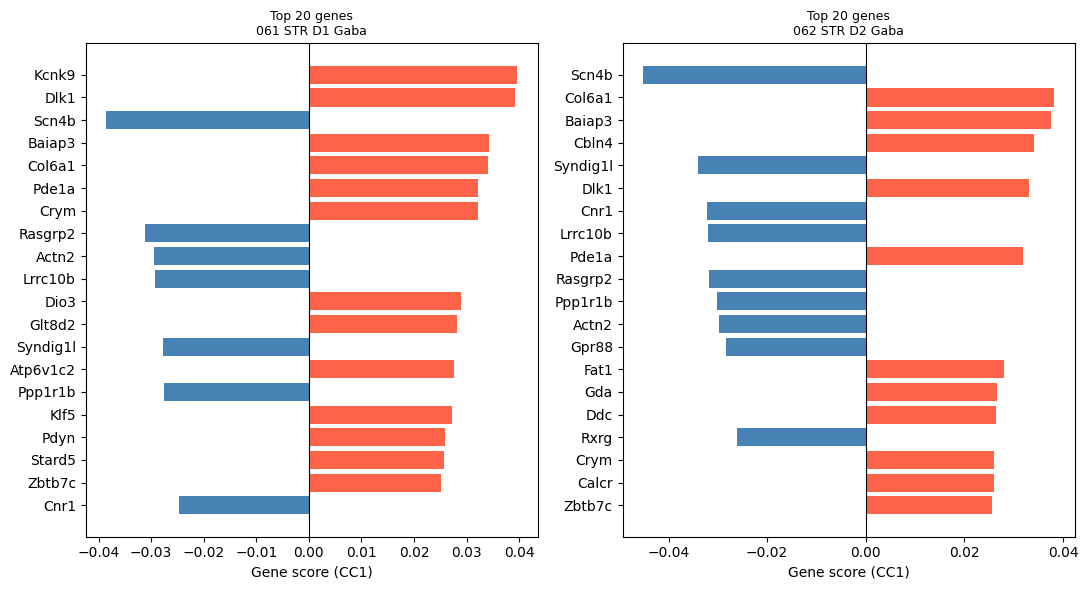

In [12]:
sigma = obj.sigma_value_choice
top_n = 20

fig, axes = plt.subplots(1, 2, figsize=(11, 6))

for ax, ct in zip(axes, [CELL_TYPE_A, CELL_TYPE_B]):
    gs = obj.gene_scores[f"geneScores|sigma{sigma}|{ct}"][:, 0]  # (n_genes,)

    gene_score_df = pd.DataFrame({"gene": gene_names, "score": gs})
    gene_score_df = gene_score_df.reindex(
        gene_score_df["score"].abs().sort_values(ascending=False).index
    )
    top_genes = gene_score_df.head(top_n)

    colors = ["tomato" if s > 0 else "steelblue" for s in top_genes["score"]]
    ax.barh(top_genes["gene"][::-1], top_genes["score"][::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Gene score (CC1)")
    ax.set_title(f"Top {top_n} genes\n{ct}", fontsize=9)

plt.tight_layout()
plt.show()

## References

**CoPro method:**  
Miao Z. et al. *CoPro: Unsupervised detection of coordinated spatial progressions in spatial transcriptomics* (in preparation).

**MERFISH data:**  
Zhang, M., Pan, X., Jung, W. *et al.* Molecularly defined and spatially resolved cell atlas of the whole mouse brain. *Nature* 624, 343–354 (2023). https://doi.org/10.1038/s41586-023-06808-9